In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import cv2
from PIL import Image
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

2026-05-08 19:07:55.618836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778267275.848532      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778267275.913856      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778267276.480170      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778267276.480217      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778267276.480220      57 computation_placer.cc:177] computation placer alr

In [2]:
BASE_PATH = "/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT"
print(os.listdir(BASE_PATH))

['SeaLake', 'Highway', 'River', 'Pasture', 'Industrial', 'Residential', 'PermanentCrop', 'validation.csv', 'AnnualCrop', 'train.csv', 'test.csv', 'label_map.json', 'Forest', 'HerbaceousVegetation']


In [3]:
train_df = pd.read_csv(os.path.join(BASE_PATH, 'train.csv'))
val_df   = pd.read_csv(os.path.join(BASE_PATH, 'validation.csv'))
test_df  = pd.read_csv(os.path.join(BASE_PATH, 'test.csv'))

for df in [train_df, val_df, test_df]:
    df['full_path'] = df['Filename'].apply(lambda x: os.path.join(BASE_PATH, x))
    df['Label_str'] = df['Label'].astype(str)

# ── CRITICAL: Build classes list sorted by Label integer ──────────────────────
# classes[i] must equal the ClassName whose Label == i
# Using .unique() or .sort_values('ClassName') gives WRONG order!
label_map = (
    train_df[['Label', 'ClassName']]
    .drop_duplicates()
    .sort_values('Label')          # sort by numeric label 0,1,2,...
    .set_index('Label')['ClassName']
)
classes = label_map.tolist()       # classes[0] = ClassName where Label=0 ✅
NUM_CLASSES = len(classes)

print('Label → ClassName mapping (must match model output nodes):')
for lbl, cls in enumerate(classes):
    print(f'  Label {lbl} → {cls}')

train_df.head()


Label → ClassName mapping (must match model output nodes):
  Label 0 → AnnualCrop
  Label 1 → Forest
  Label 2 → HerbaceousVegetation
  Label 3 → Highway
  Label 4 → Industrial
  Label 5 → Pasture
  Label 6 → PermanentCrop
  Label 7 → Residential
  Label 8 → River
  Label 9 → SeaLake


,Unnamed: 0,Filename,Label,ClassName,full_path,Label_str
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop,/kaggle/input/datasets/apollo2506/eurosat-data...,0
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation,/kaggle/input/datasets/apollo2506/eurosat-data...,2
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop,/kaggle/input/datasets/apollo2506/eurosat-data...,6
3,2223,Industrial/Industrial_453.jpg,4,Industrial,/kaggle/input/datasets/apollo2506/eurosat-data...,4
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation,/kaggle/input/datasets/apollo2506/eurosat-data...,2


In [4]:
print(f"Train:      {len(train_df):,} images")
print(f"Validation: {len(val_df):,} images")
print(f"Test:       {len(test_df):,} images")

Train:      18,900 images
Validation: 5,400 images
Test:       2,700 images


In [5]:
train_df['full_path'][0]

'/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/AnnualCrop/AnnualCrop_142.jpg'

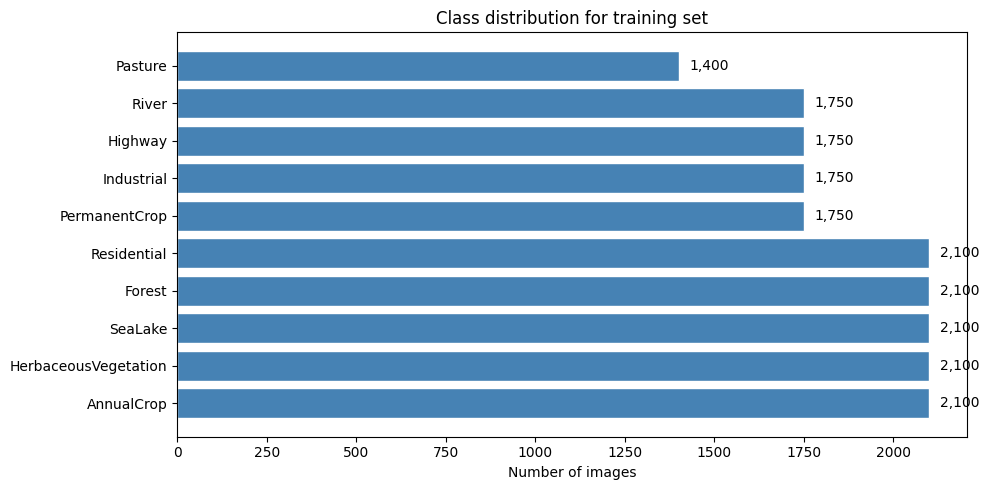

In [6]:
class_counts = train_df["ClassName"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(class_counts.index, class_counts.values,
               color="steelblue", edgecolor="white")

for bar, val in zip(bars, class_counts.values):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=10)

ax.set_xlabel("Number of images")
ax.set_title("Class distribution for training set")
plt.tight_layout()
plt.show()

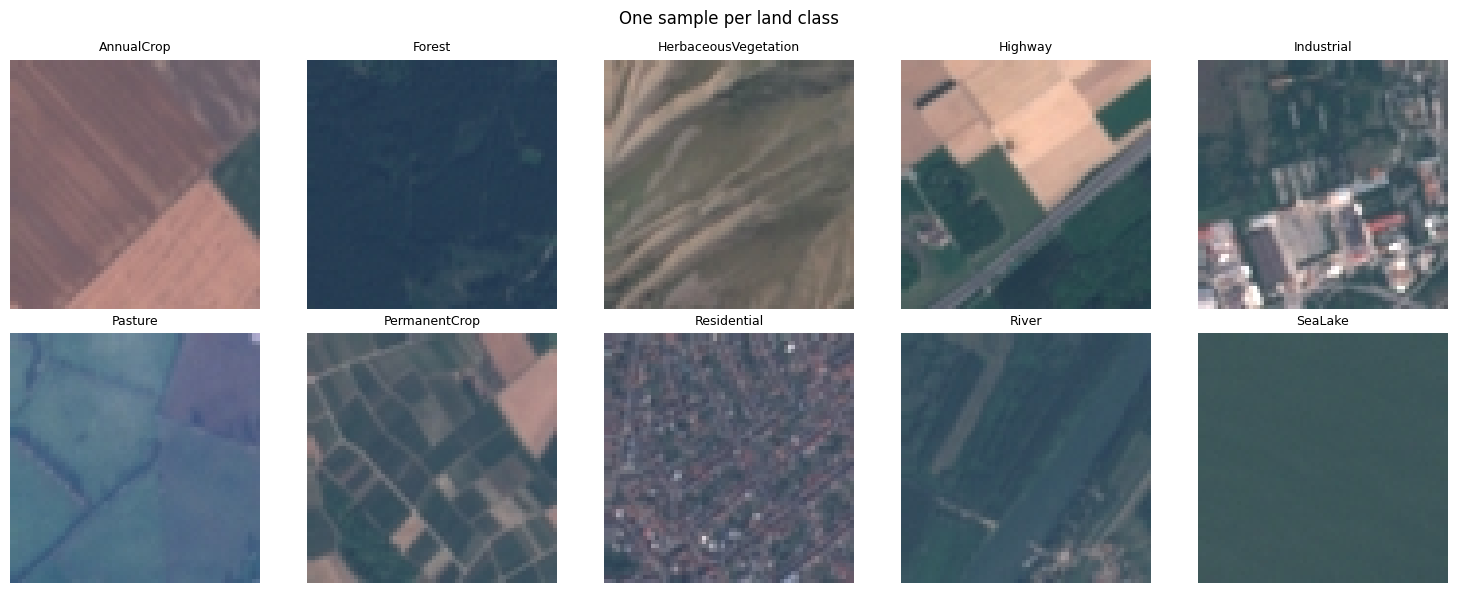

In [7]:
classes = train_df["ClassName"].unique()
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(sorted(classes)):
    row = train_df[train_df["ClassName"] == cls].iloc[10]
    img = Image.open(row["full_path"])
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis("off")

plt.suptitle("One sample per land class")
plt.tight_layout()
plt.show()

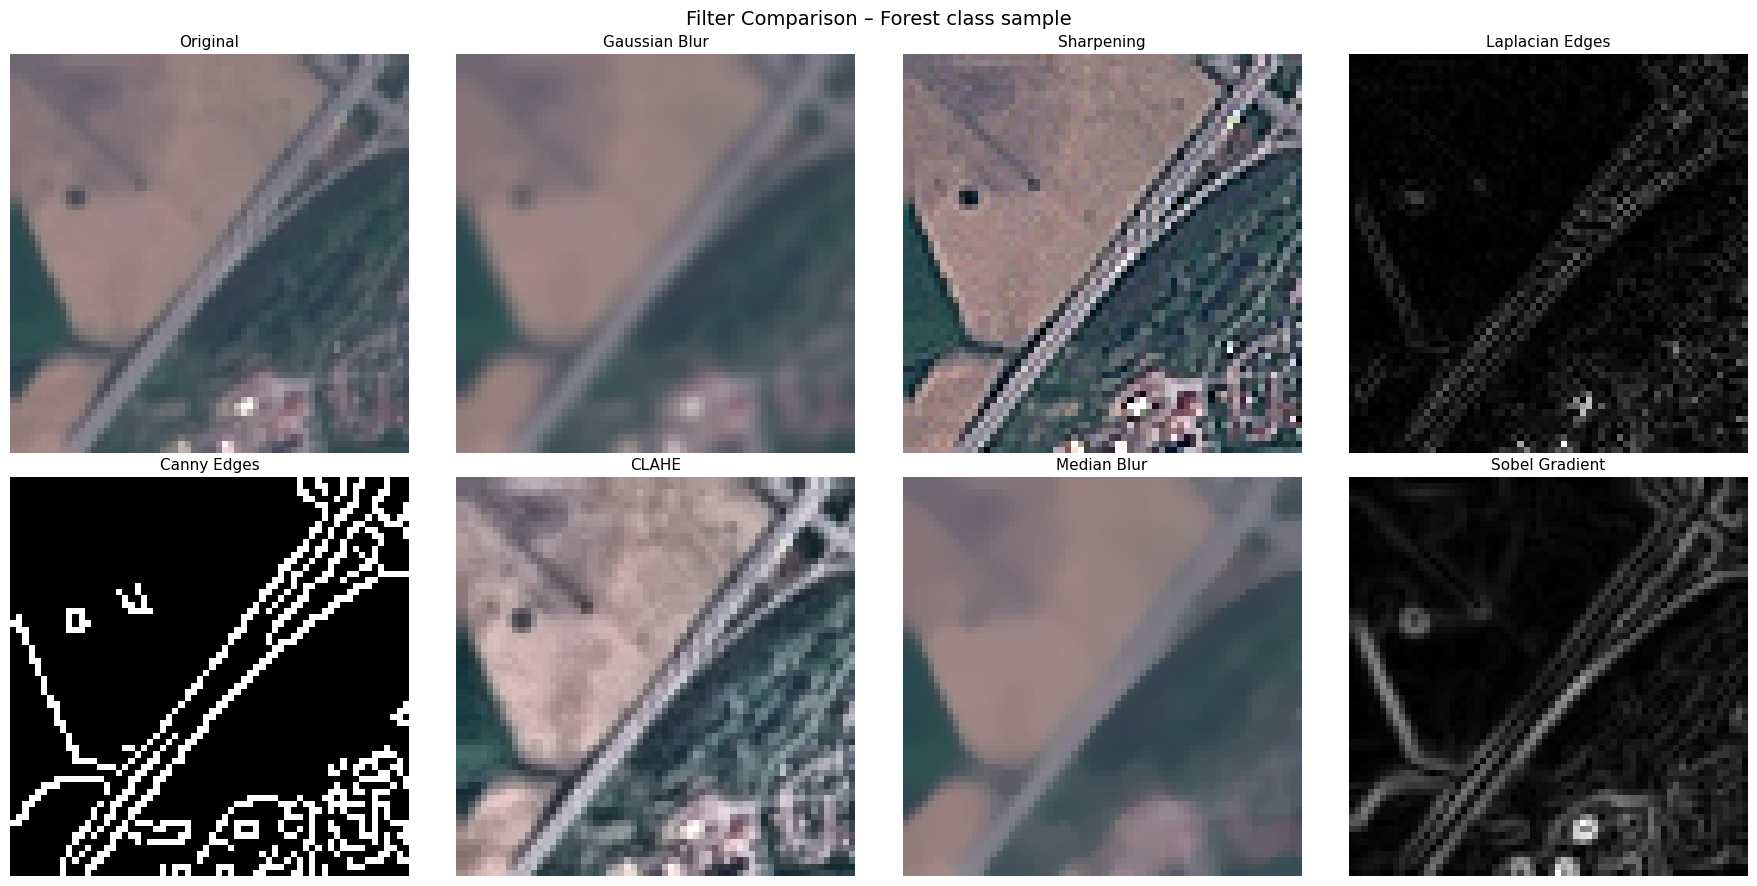

In [8]:
# Pick one representative image per class for filter demo
sample_row = train_df[train_df['ClassName'] == 'Highway'].iloc[50]
raw_img    = cv2.imread(sample_row['full_path'])
raw_rgb    = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

def apply_filters(img_bgr):
    """Return dict of filter_name → filtered RGB image."""
    results = {}
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results['Original'] = rgb

    # 1. Gaussian blur – noise reduction
    blurred = cv2.GaussianBlur(img_bgr, (5, 5), 0)
    results['Gaussian Blur'] = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

    # 2. Sharpening – highlight fine textures (roads, fields boundaries)
    kernel_sharp = np.array([[ 0, -1,  0],
                              [-1,  5, -1],
                              [ 0, -1,  0]])
    sharpened = cv2.filter2D(img_bgr, -1, kernel_sharp)
    results['Sharpening'] = cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)

    # 3. Laplacian edge detection
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lap  = cv2.Laplacian(gray, cv2.CV_64F)
    lap  = np.uint8(np.clip(np.abs(lap), 0, 255))
    results['Laplacian Edges'] = cv2.cvtColor(lap, cv2.COLOR_GRAY2RGB)

    # 4. Canny edges
    canny = cv2.Canny(gray, 50, 150)
    results['Canny Edges'] = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

    # 5. CLAHE – contrast limited adaptive histogram equalisation (great for satellite)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    clahe_img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    results['CLAHE'] = clahe_img

    # 6. Median blur – salt-and-pepper noise removal
    median = cv2.medianBlur(img_bgr, 5)
    results['Median Blur'] = cv2.cvtColor(median, cv2.COLOR_BGR2RGB)

    # 7. Sobel gradient (X + Y magnitude)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel  = np.sqrt(sobelx**2 + sobely**2)
    sobel  = np.uint8(np.clip(sobel / sobel.max() * 255, 0, 255))
    results['Sobel Gradient'] = cv2.cvtColor(sobel, cv2.COLOR_GRAY2RGB)

    # 8. Unsharp mask
    gaussian = cv2.GaussianBlur(img_bgr, (9, 9), 10)
    unsharp  = cv2.addWeighted(img_bgr, 1.5, gaussian, -0.5, 0)
    results['Unsharp Mask'] = cv2.cvtColor(unsharp, cv2.COLOR_BGR2RGB)

    return results

filtered = apply_filters(raw_img)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, (name, img) in zip(axes, filtered.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=11)
    ax.axis('off')
plt.suptitle('Filter Comparison – Forest class sample', fontsize=14)
plt.tight_layout()
plt.show()

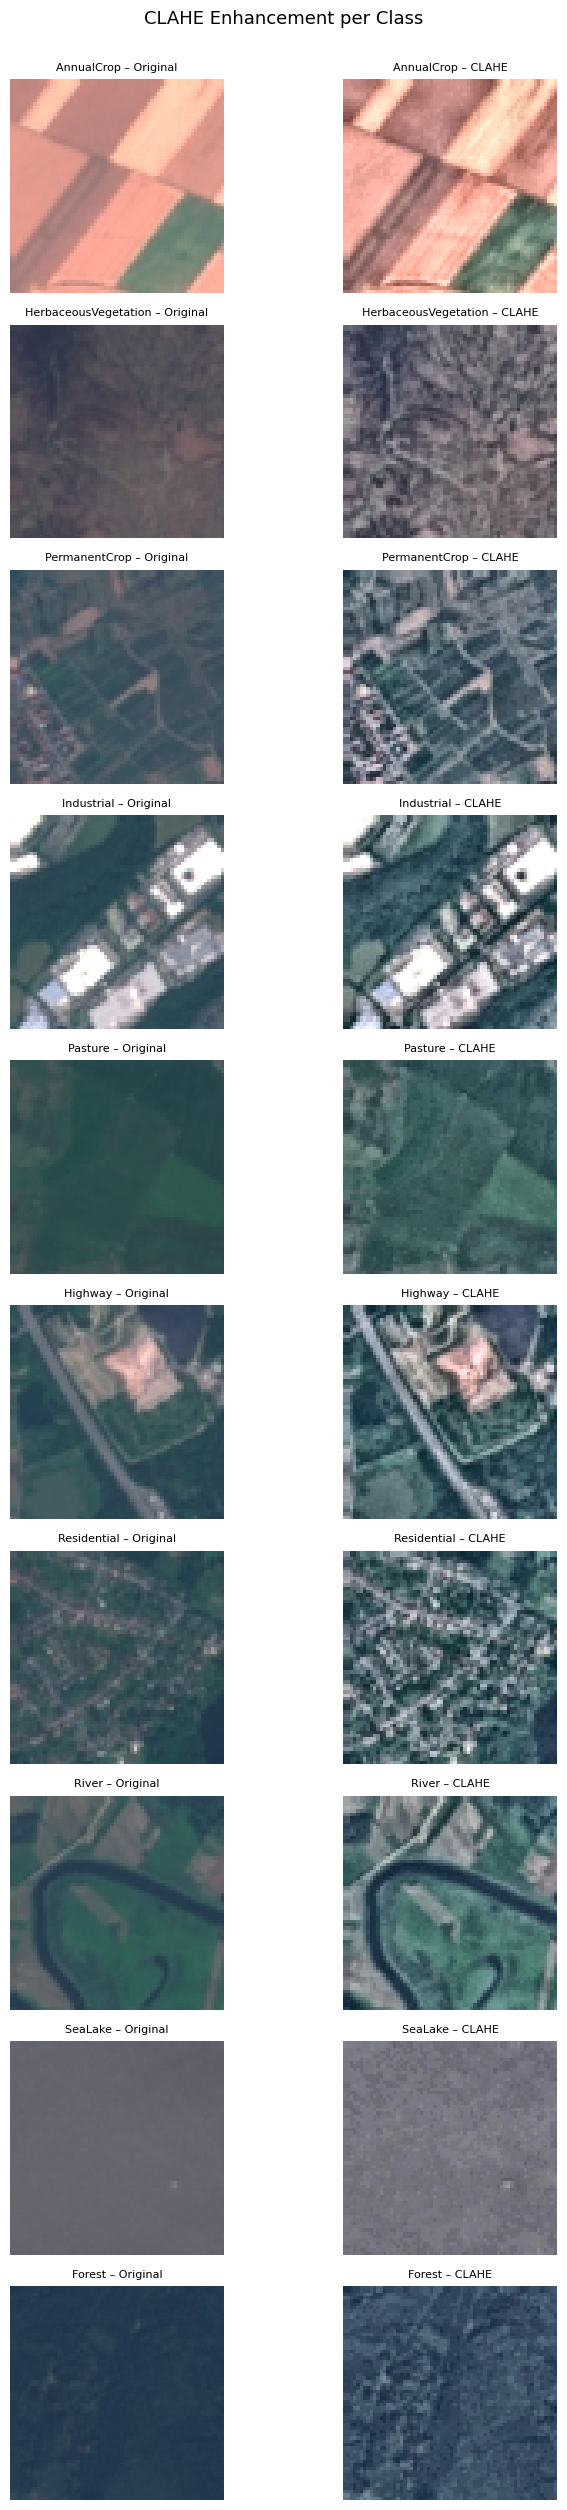

In [9]:
# Show CLAHE effect across multiple classes
fig, axes = plt.subplots(10, 2, figsize=(8, 10 * 2.5))
for i, cls in enumerate(classes):
    row = train_df[train_df['ClassName'] == cls].iloc[3]
    bgr = cv2.imread(row['full_path'])

    # Original
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # CLAHE
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    clahe_rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    axes[i][0].imshow(rgb);       axes[i][0].set_title(f'{cls} – Original', fontsize=8); axes[i][0].axis('off')
    axes[i][1].imshow(clahe_rgb); axes[i][1].set_title(f'{cls} – CLAHE',    fontsize=8); axes[i][1].axis('off')

plt.suptitle('CLAHE Enhancement per Class', fontsize=13, y=1.002)
plt.tight_layout()
plt.show()

In [10]:
# ── Custom per-class metrics for multi-class problems ────────────────────────
# Keras built-ins that show live in the progress bar:
#   • accuracy          – overall fraction correct
#   • top_k_categorical_accuracy (k=3) – is true class in top-3 predictions?
#   • AUC               – macro-averaged one-vs-rest AUC
#   • Precision / Recall – macro-averaged across all classes

NUM_CLASSES_FOR_METRICS = len(train_df['ClassName'].unique())   # needed below

def get_metrics():
    """Return a fresh list of Keras metric objects (must be re-created for each model)."""
    return [
        keras.metrics.CategoricalAccuracy(name='accuracy'),
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy'),
        keras.metrics.AUC(name='auc', multi_label=False),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]

print('Metrics defined: accuracy | top3_accuracy | auc | precision | recall')


Metrics defined: accuracy | top3_accuracy | auc | precision | recall


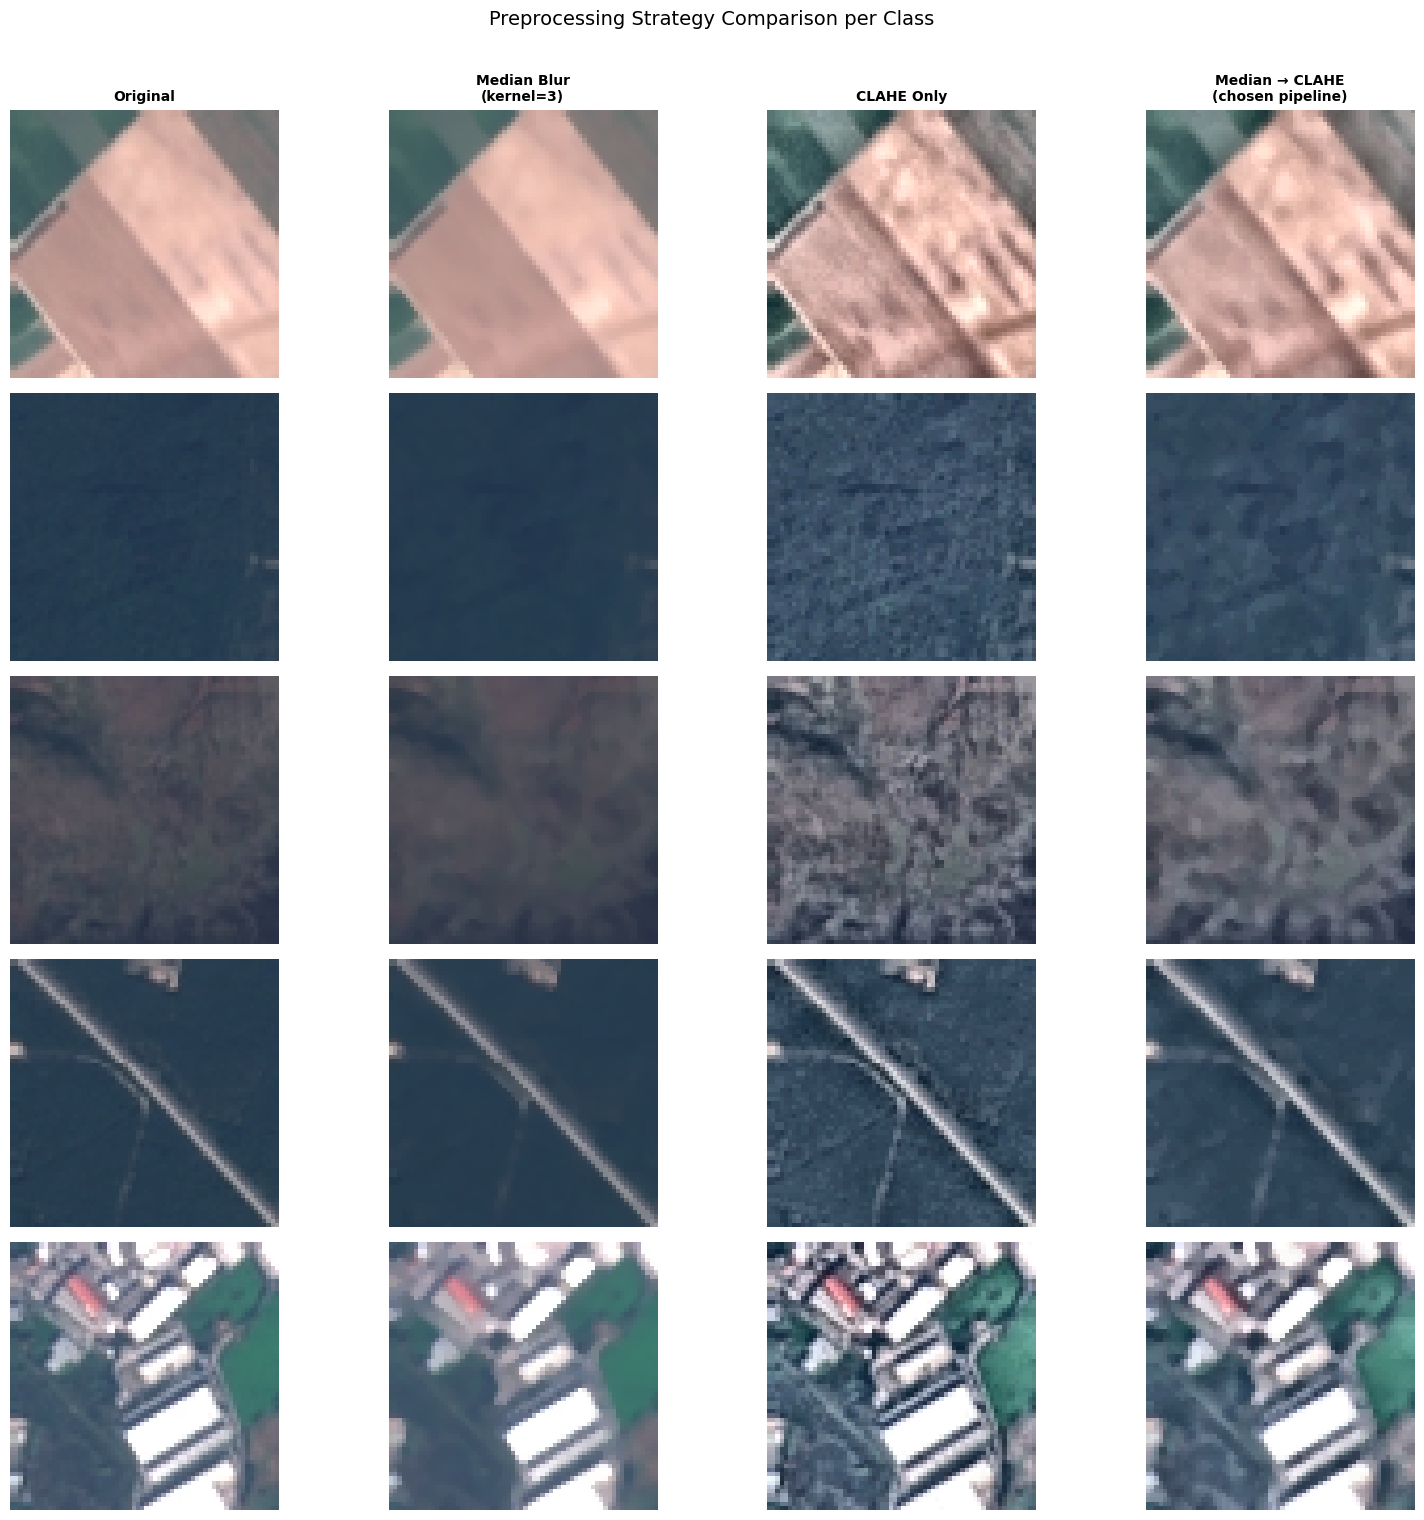

Chosen pipeline: Median Blur (kernel=3) → CLAHE
  • Median Blur: removes sensor noise without blurring edges
  • CLAHE:       enhances local contrast to reveal class-discriminative texture

Train batches: 1182
Val   batches: 338
Test  batches: 169
Batch shape: X=(16, 64, 64, 3), y=(16, 10)


In [11]:
IMG_SIZE  = 64     # resize to 64×64 (use 224 for EfficientNet – see below)
BATCH     = 16
NUM_CLASSES = len(train_df['ClassName'].unique())

# ── Compare preprocessing strategies visually ─────────────────────────────────
sample_row = train_df[train_df['ClassName'] == 'Forest'].iloc[0]
bgr_raw    = cv2.imread(sample_row['full_path'])
rgb_raw    = cv2.cvtColor(bgr_raw, cv2.COLOR_BGR2RGB)

def preprocess_none(rgb):       # baseline
    return rgb.astype(np.float32) / 255.0

def preprocess_clahe_only(rgb):
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB).astype(np.float32) / 255.0

def preprocess_median_only(rgb):
    bgr     = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    denoised = cv2.medianBlur(bgr, 3)          # kernel=3 to preserve edge detail
    return cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

def preprocess_median_then_clahe(rgb):          # ← COMBINED (best of both)
    """Step 1 – Median Blur removes salt-and-pepper sensor noise.
    Step 2 – CLAHE boosts local contrast so the CNN sees texture detail."""
    bgr      = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    denoised = cv2.medianBlur(bgr, 3)           # kernel=3 keeps fine structure
    lab      = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return enhanced.astype(np.float32) / 255.0

# Visual comparison across 3 representative classes
demo_classes   = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial']
pipeline_fns   = [preprocess_none, preprocess_median_only,
                  preprocess_clahe_only, preprocess_median_then_clahe]
pipeline_names = ['Original', 'Median Blur\n(kernel=3)',
                  'CLAHE Only', 'Median → CLAHE\n(chosen pipeline)']

fig, axes = plt.subplots(len(demo_classes), 4, figsize=(16, len(demo_classes)*3))
for row_i, cls in enumerate(demo_classes):
    sample = train_df[train_df['ClassName'] == cls].iloc[0]
    bgr    = cv2.imread(sample['full_path'])
    rgb    = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    for col_i, (fn, name) in enumerate(zip(pipeline_fns, pipeline_names)):
        processed = fn(rgb)
        ax = axes[row_i][col_i]
        ax.imshow(processed)
        if row_i == 0: ax.set_title(name, fontsize=10, fontweight='bold')
        if col_i == 0: ax.set_ylabel(cls, fontsize=9, rotation=0, labelpad=70, va='center')
        ax.axis('off')
        # Highlight the chosen pipeline
        if col_i == 3:
            for spine in ax.spines.values():
                spine.set_edgecolor('limegreen'); spine.set_linewidth(3); spine.set_visible(True)

plt.suptitle('Preprocessing Strategy Comparison per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Chosen pipeline: Median Blur (kernel=3) → CLAHE')
print('  • Median Blur: removes sensor noise without blurring edges')
print('  • CLAHE:       enhances local contrast to reveal class-discriminative texture')

# ── Final preprocessing function used in the pipeline ─────────────────────────
def apply_preprocessing(img_array):
    """Median Blur denoising → CLAHE contrast enhancement.
    Input:  uint8 RGB numpy array
    Output: float32 RGB numpy array in [0, 1]
    """
    bgr      = cv2.cvtColor(img_array.astype(np.uint8), cv2.COLOR_RGB2BGR)
    denoised = cv2.medianBlur(bgr, 3)                # Step 1: denoise
    lab      = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])         # Step 2: CLAHE on L channel
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return enhanced.astype(np.float32) / 255.0

# ── Custom Keras Sequence ──────────────────────────────────────────────────────
from tensorflow.keras.utils import Sequence

class EuroSATSequence(Sequence):
    def __init__(self, df, img_size=64, batch_size=32, augment=False):
        self.df         = df.reset_index(drop=True)
        self.img_size   = img_size
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx+1) * self.batch_size]
        batch_df  = self.df.iloc[batch_idx]

        X, y = [], []
        for _, row in batch_df.iterrows():
            img = Image.open(row['full_path']).convert('RGB')
            img = img.resize((self.img_size, self.img_size))
            arr = np.array(img)

            # Combined preprocessing: Median Blur → CLAHE
            arr = apply_preprocessing(arr)

            if self.augment:
                if np.random.rand() > 0.5: arr = np.fliplr(arr)
                if np.random.rand() > 0.5: arr = np.flipud(arr)
                k = np.random.choice([0, 1, 2, 3])
                arr = np.rot90(arr, k=k)
                factor = 1.0 + np.random.uniform(-0.2, 0.2)
                arr    = np.clip(arr * factor, 0, 1)

            X.append(arr)
            y.append(int(row['Label']))

        return np.array(X, dtype=np.float32), tf.keras.utils.to_categorical(y, num_classes=NUM_CLASSES)

    def on_epoch_end(self):
        if self.augment:
            np.random.shuffle(self.indices)


train_seq = EuroSATSequence(train_df, img_size=IMG_SIZE, batch_size=BATCH, augment=True)
val_seq   = EuroSATSequence(val_df,   img_size=IMG_SIZE, batch_size=BATCH, augment=False)
test_seq  = EuroSATSequence(test_df,  img_size=IMG_SIZE, batch_size=BATCH, augment=False)

print(f'\nTrain batches: {len(train_seq)}')
print(f'Val   batches: {len(val_seq)}')
print(f'Test  batches: {len(test_seq)}')
X_batch, y_batch = train_seq[0]
print(f'Batch shape: X={X_batch.shape}, y={y_batch.shape}')


# Custom CNN

In [12]:
def build_cnn(input_shape=(64, 64, 3), num_classes=10):
    """
    Custom CNN:
    3 × [Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout]
    + GlobalAveragePooling + Dense head
    """
    inp = layers.Input(shape=input_shape)

    # Block 1 – 32 filters
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2 – 64 filters
    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3 – 128 filters
    x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.30)(x)

    # Block 4 – 256 filters
    x = layers.Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.30)(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out, name='Custom_CNN')
    return model


cnn_model = build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)
cnn_model.summary()

I0000 00:00:1778267306.860781      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 654,378 (2.50 MB)

 Trainable params: 652,458 (2.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [13]:
# Compile CNN
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=get_metrics()
)

# Callbacks
cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

# Train CNN
print('Training Custom CNN...')
cnn_history = cnn_model.fit(
    train_seq,
    epochs=70,
    validation_data=val_seq,
    callbacks=cnn_callbacks,
    verbose=1
)

Training Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/70


I0000 00:00:1778267314.819515     130 service.cc:152] XLA service 0x7a3090003b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778267314.819550     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778267315.994965     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


   3/1182 ━━━━━━━━━━━━━━━━━━━━ 1:38 84ms/step - accuracy: 0.1562 - auc: 0.6207 - loss: 2.8395 - precision: 0.0883 - recall: 0.0347 - top3_accuracy: 0.4896          

I0000 00:00:1778267324.688313     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.4699 - auc: 0.8623 - loss: 1.6157 - precision: 0.5734 - recall: 0.3527 - top3_accuracy: 0.7980
Epoch 1: val_accuracy improved from -inf to 0.53963, saving model to best_cnn.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 237s 187ms/step - accuracy: 0.4699 - auc: 0.8623 - loss: 1.6154 - precision: 0.5735 - recall: 0.3528 - top3_accuracy: 0.7980 - val_accuracy: 0.5396 - val_auc: 0.9101 - val_loss: 1.4632 - val_precision: 0.5527 - val_recall: 0.4952 - val_top3_accuracy: 0.9204 - learning_rate: 0.0010
Epoch 2/70
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6998 - auc: 0.9575 - loss: 0.8856 - precision: 0.7703 - recall: 0.6231 - top3_accuracy: 0.9370
Epoch 2: val_accuracy improved from 0.53963 to 0.61148, saving model to best_cnn.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - accuracy: 0.6998 - auc: 0.9575 - loss: 0.8856 - precision: 0.7703 - recall: 0.6231 - top3_accuracy: 0.9370 - val_accuracy: 0.6115 - val_auc: 0.9051 - v

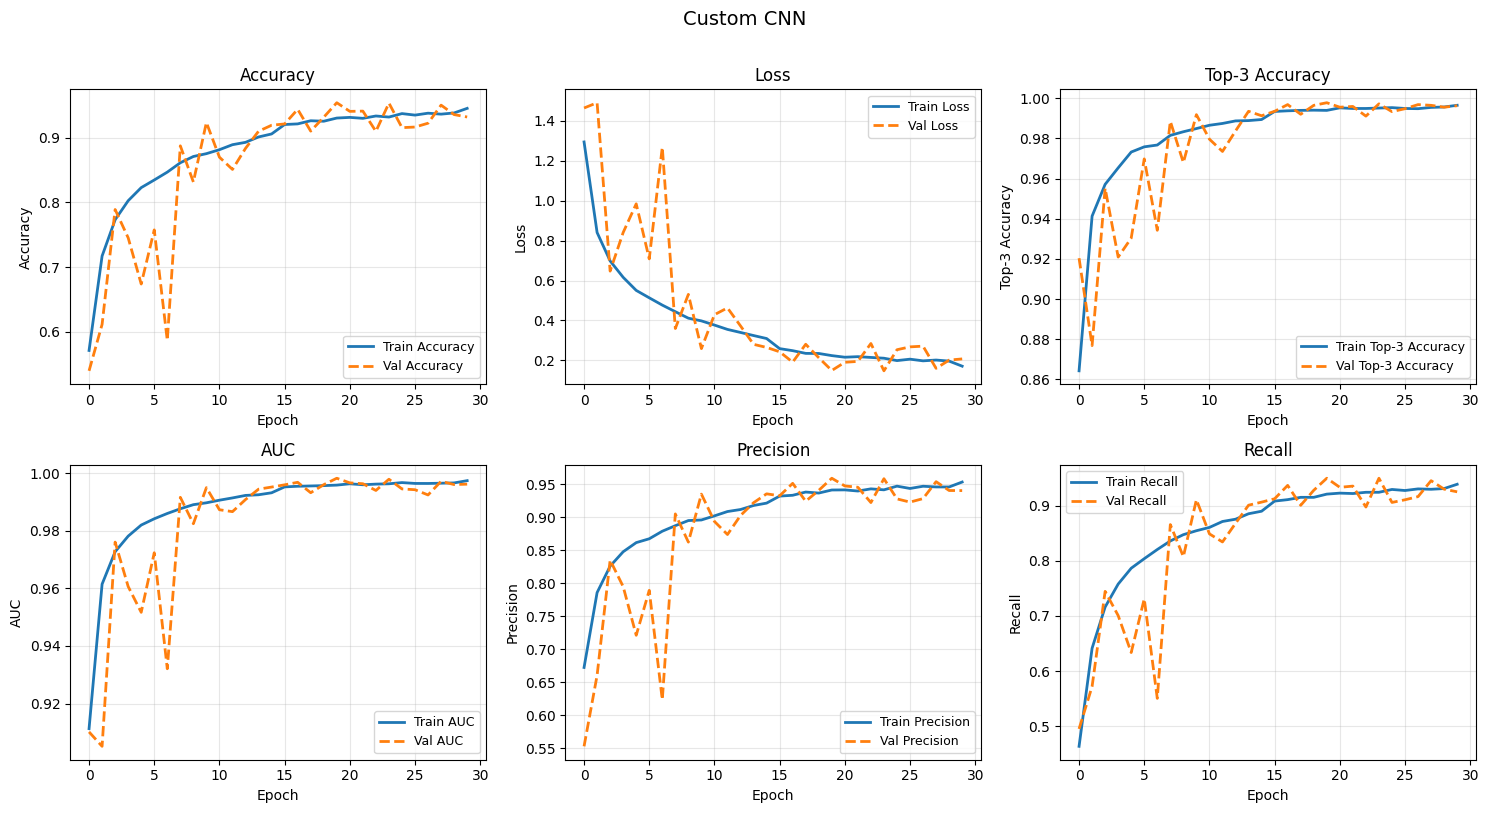

In [14]:
def plot_history(history, title='Training History'):
    hist = history.history
    metrics_to_plot = [
        ('accuracy',     'val_accuracy',     'Accuracy'),
        ('loss',         'val_loss',         'Loss'),
        ('top3_accuracy','val_top3_accuracy', 'Top-3 Accuracy'),
        ('auc',          'val_auc',          'AUC'),
        ('precision',    'val_precision',    'Precision'),
        ('recall',       'val_recall',       'Recall'),
    ]
    # Only plot metrics that actually exist in history
    available = [(tr, vl, lbl) for tr, vl, lbl in metrics_to_plot if tr in hist]

    cols = 3
    rows = int(np.ceil(len(available) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = np.array(axes).flatten()

    for ax, (tr_key, vl_key, label) in zip(axes, available):
        ax.plot(hist[tr_key], label=f'Train {label}', linewidth=2)
        if vl_key in hist:
            ax.plot(hist[vl_key], label=f'Val {label}', linewidth=2, linestyle='--')
        ax.set_title(f'{label}', fontsize=12)
        ax.set_xlabel('Epoch'); ax.set_ylabel(label)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    for ax in axes[len(available):]:
        ax.axis('off')

    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

plot_history(cnn_history, 'Custom CNN')


In [15]:
# Evaluate CNN on test set
# model.evaluate() returns [loss, accuracy, top3_accuracy, auc, precision, recall]
cnn_results = cnn_model.evaluate(test_seq, verbose=1)
cnn_metric_names = ['loss', 'accuracy', 'top3_accuracy', 'auc', 'precision', 'recall']

print('\n── Custom CNN – Test Results ──')
for name, val in zip(cnn_metric_names, cnn_results):
    print(f'  {name:<15}: {val:.4f}')

# Keep individual variables for the comparison table later
cnn_test_loss, cnn_test_acc, cnn_test_top3, cnn_test_auc, cnn_test_prec, cnn_test_rec = cnn_results


169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 149ms/step - accuracy: 0.9557 - auc: 0.9976 - loss: 0.1425 - precision: 0.9600 - recall: 0.9516 - top3_accuracy: 0.9952

── Custom CNN – Test Results ──
  loss           : 0.1337
  accuracy       : 0.9567
  top3_accuracy  : 0.9970
  auc            : 0.9985
  precision      : 0.9618
  recall         : 0.9522


In [16]:
# ── Safe prediction helper ────────────────────────────────────────────────────

def get_predictions(model, sequence):
    """Run inference over a full EuroSATSequence safely.
    Collects ALL batches into memory first, then calls predict() once.
    Returns (y_true, y_pred) as flat integer numpy arrays.
    """
    all_X = []
    all_y = []

    for i in range(len(sequence)):
        X_b, y_b = sequence[i]          # load batch from disk
        all_X.append(X_b)
        all_y.append(y_b)

    # Concatenate BOTH arrays before predict
    X_all  = np.concatenate(all_X, axis=0)   # shape: (N, H, W, 3)
    y_all  = np.concatenate(all_y, axis=0)   # shape: (N, num_classes)

    # Single predict call — no loop, no TF internal state conflict
    preds  = model.predict(X_all, batch_size=64, verbose=1)

    y_true = np.argmax(y_all,  axis=1)       # integer class indices
    y_pred = np.argmax(preds,  axis=1)
    return y_true, y_pred

print('get_predictions() helper ready.')
print(f'  test  samples: {len(test_df)}')
print(f'  test  batches: {len(test_seq)}')


get_predictions() helper ready.
  test  samples: 2700
  test  batches: 169


Running predictions on test set (CNN)...
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step

Classification Report – Custom CNN
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.97      0.96       300
HerbaceousVegetation       0.98      0.99      0.98       300
       PermanentCrop       0.91      0.94      0.92       300
          Industrial       0.96      0.96      0.96       250
             Pasture       0.99      0.94      0.97       250
             Highway       0.94      0.93      0.93       200
         Residential       0.90      0.90      0.90       250
               River       0.96      1.00      0.98       300
             SeaLake       0.98      0.92      0.95       250
              Forest       0.99      0.98      0.99       300

            accuracy                           0.96      2700
           macro avg       0.96      0.95      0.96      2700
        weighted avg       0.96      0.96      0.96      2700



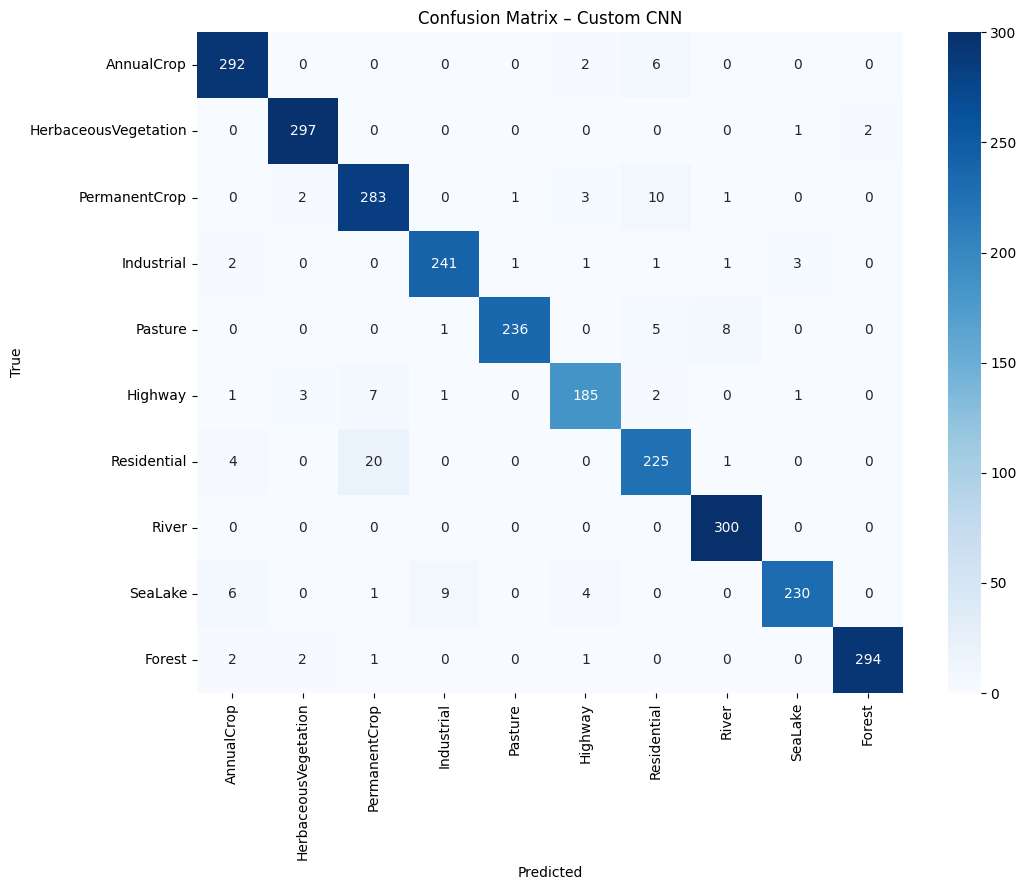

In [17]:
# Confusion matrix & classification report – CNN
print('Running predictions on test set (CNN)...')
y_true_cnn, y_pred_cnn = get_predictions(cnn_model, test_seq)

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
print('\nClassification Report – Custom CNN')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=classes))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix – Custom CNN')
plt.tight_layout()
plt.show()


# EfficientNet B3

In [18]:
IMG_SIZE_EFF = 224

train_seq_eff = EuroSATSequence(train_df, img_size=IMG_SIZE_EFF, batch_size=BATCH, augment=True)
val_seq_eff   = EuroSATSequence(val_df,   img_size=IMG_SIZE_EFF, batch_size=BATCH, augment=False)
test_seq_eff  = EuroSATSequence(test_df,  img_size=IMG_SIZE_EFF, batch_size=BATCH, augment=False)

print('EfficientNet data sequences ready.')

EfficientNet data sequences ready.


In [19]:
def build_efficientnet(input_shape=(224, 224, 3), num_classes=10):
    """
    Two-phase transfer learning:
      Phase 1 – freeze the base, train only the head
      Phase 2 – unfreeze top layers, fine-tune end-to-end
    """
    base = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False  # freeze for phase 1

    inp = layers.Input(shape=input_shape)
    # EfficientNet expects pixel values in [0,255] but our CLAHE outputs [0,1]
    # → rescale here
    x = layers.Rescaling(255.0)(inp)
    x = base(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out, name='EfficientNetB3_TL')
    return model, base


eff_model, eff_base = build_efficientnet(input_shape=(IMG_SIZE_EFF, IMG_SIZE_EFF, 3), num_classes=NUM_CLASSES)
eff_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB3_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,710,521 (44.67 MB)

 Trainable params: 923,914 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

Phase 1: Training classification head...
Progress bar shows: loss | accuracy | top3_accuracy | auc | precision | recall


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7608 - auc: 0.9583 - loss: 0.8753 - precision: 0.8084 - recall: 0.7340 - top3_accuracy: 0.9322
Epoch 1: val_accuracy improved from -inf to 0.92019, saving model to best_efficientnet_phase1.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 247s 170ms/step - accuracy: 0.7608 - auc: 0.9583 - loss: 0.8751 - precision: 0.8085 - recall: 0.7341 - top3_accuracy: 0.9322 - val_accuracy: 0.9202 - val_auc: 0.9953 - val_loss: 0.3433 - val_precision: 0.9355 - val_recall: 0.9057 - val_top3_accuracy: 0.9961 - learning_rate: 0.0010
Epoch 2/40
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.8739 - auc: 0.9868 - loss: 0.5286 - precision: 0.8963 - recall: 0.8501 - top3_accuracy: 0.9801
Epoch 2: val_accuracy improved from 0.92019 to 0.93593, saving model to best_efficientnet_phase1.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 157s 133ms/step - accuracy: 0.8739 - auc: 0.9868 - loss: 0.5286 - precision: 0.8963 - recall: 0.8501 - top3_accuracy: 0.980

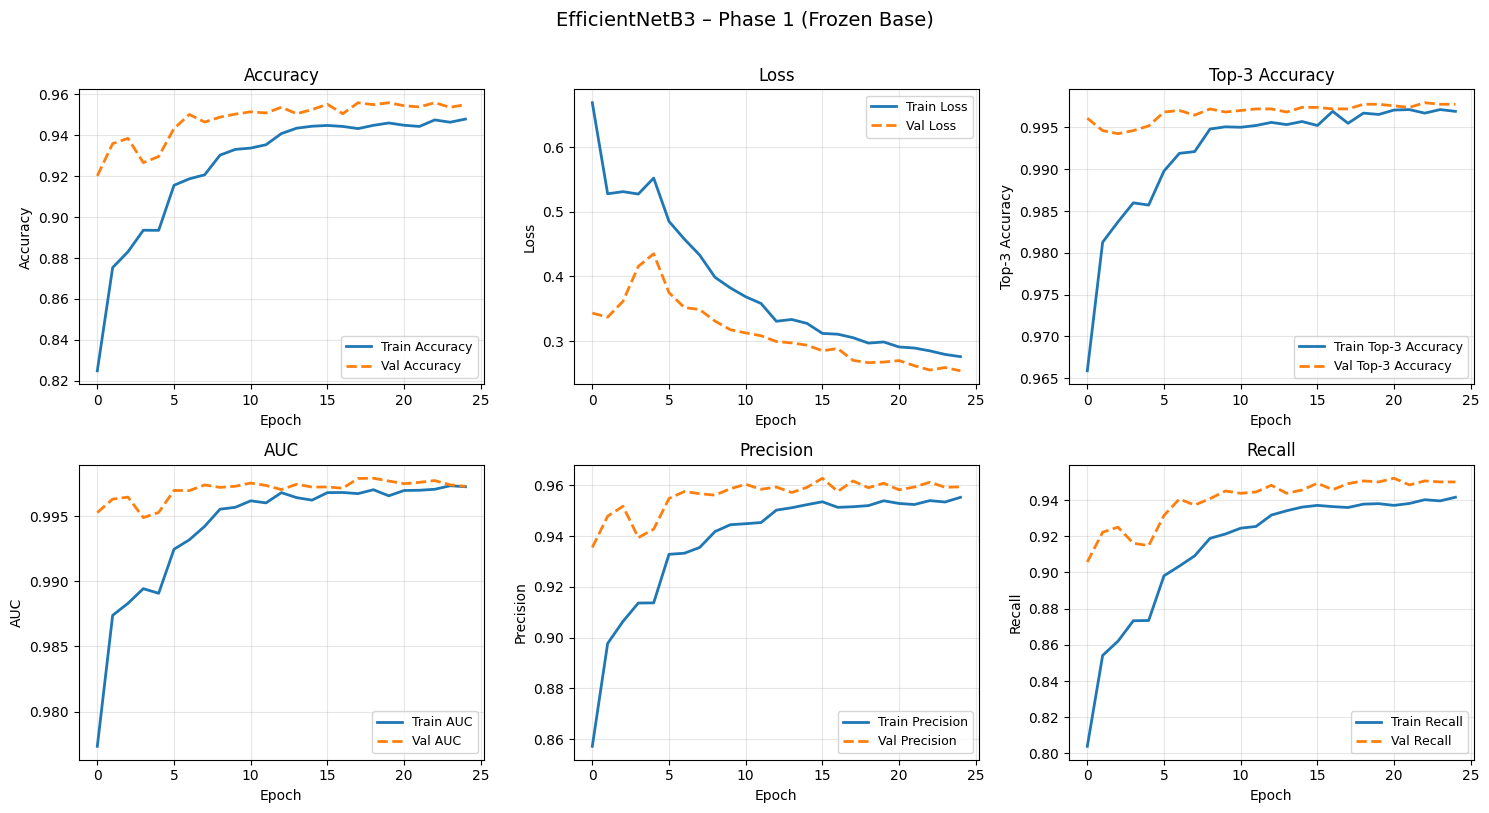

In [20]:
# ── Phase 1: Train head only ────────────────────────────────────────────────
eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=get_metrics()   # same 5 metrics
)

eff_callbacks_p1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint('best_efficientnet_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Phase 1: Training classification head...')
print('Progress bar shows: loss | accuracy | top3_accuracy | auc | precision | recall')
eff_history_p1 = eff_model.fit(
    train_seq_eff,
    epochs=40,
    validation_data=val_seq_eff,
    callbacks=eff_callbacks_p1,
    verbose=1
)

plot_history(eff_history_p1, 'EfficientNetB3 – Phase 1 (Frozen Base)')


Total EfficientNet layers: 385
Fine-tuning from layer:    154 onward
Trainable layers:          231
Phase 2: Fine-tuning EfficientNetB3...
Epoch 1/50


2026-05-08 20:43:29.424765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 20:43:29.617203: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 20:43:30.103556: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 20:43:30.319966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 20:43:30.706965: E external/local_xla/xla/stream_

1063/1182 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.7357 - auc: 0.9530 - loss: 1.0220 - precision: 0.7978 - recall: 0.6800 - top3_accuracy: 0.9225

2026-05-08 20:46:01.572355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 20:46:01.764406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 20:46:02.196744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 20:46:02.412715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7414 - auc: 0.9548 - loss: 1.0013 - precision: 0.8020 - recall: 0.6868 - top3_accuracy: 0.9253
Epoch 1: val_accuracy improved from -inf to 0.92389, saving model to best_efficientnet_final.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 292s 173ms/step - accuracy: 0.7414 - auc: 0.9548 - loss: 1.0011 - precision: 0.8020 - recall: 0.6869 - top3_accuracy: 0.9253 - val_accuracy: 0.9239 - val_auc: 0.9956 - val_loss: 0.3775 - val_precision: 0.9450 - val_recall: 0.8944 - val_top3_accuracy: 0.9941 - learning_rate: 1.0000e-05
Epoch 2/50
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8696 - auc: 0.9861 - loss: 0.5529 - precision: 0.8963 - recall: 0.8463 - top3_accuracy: 0.9794
Epoch 2: val_accuracy improved from 0.92389 to 0.94333, saving model to best_efficientnet_final.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 146s 124ms/step - accuracy: 0.8696 - auc: 0.9861 - loss: 0.5529 - precision: 0.8963 - recall: 0.8463 - top3_accuracy: 0.9794 - val_a

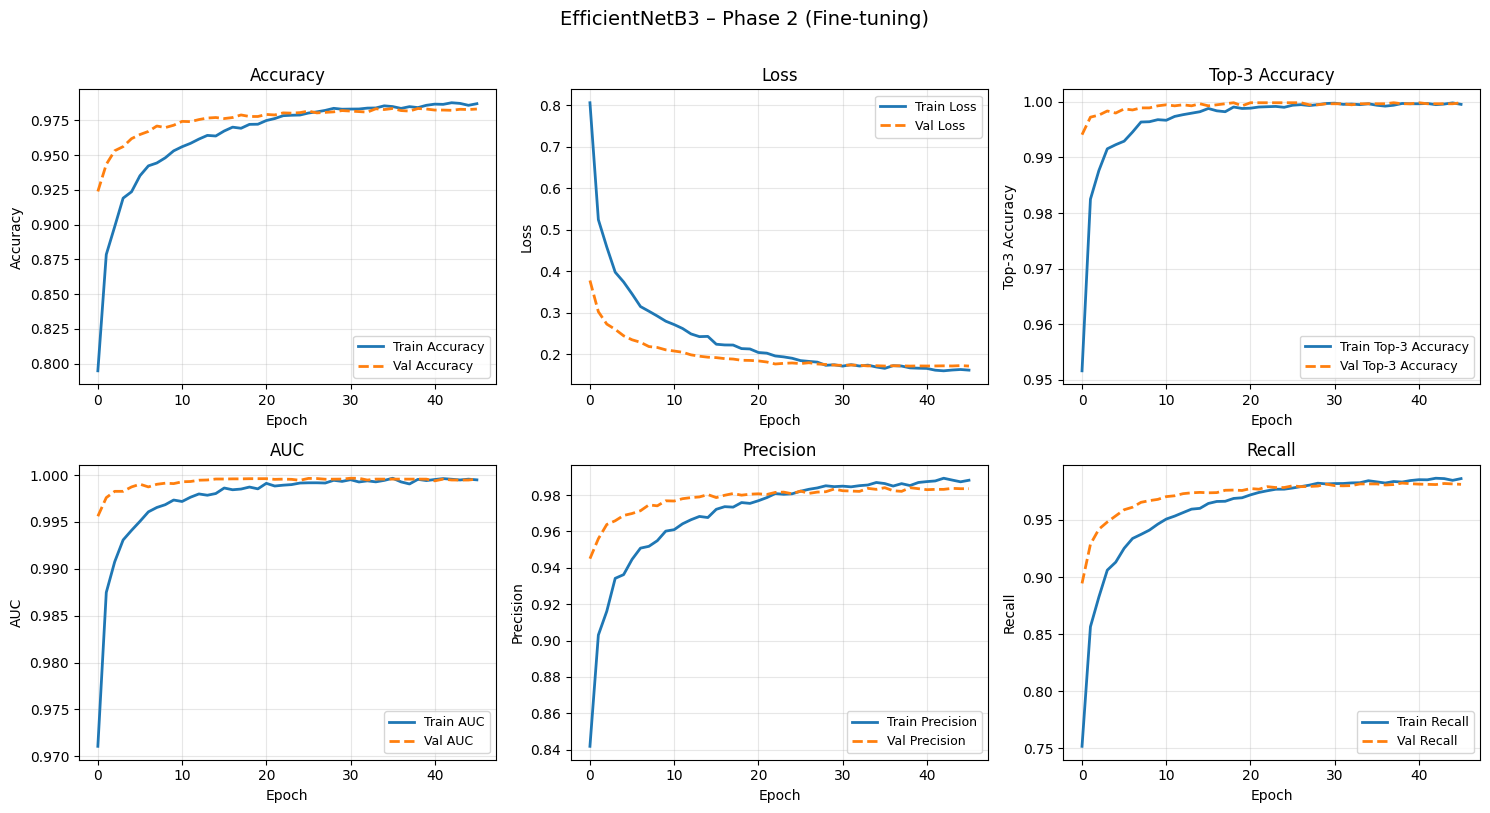

In [21]:
# ── Phase 2: Fine-tune top layers of EfficientNetB3 ───────────────────────────
# Unfreeze the top ~60% of layers
eff_base.trainable = True
total_layers = len(eff_base.layers)
fine_tune_from = int(total_layers * 0.40)

for layer in eff_base.layers[:fine_tune_from]:
    layer.trainable = False

print(f'Total EfficientNet layers: {total_layers}')
print(f'Fine-tuning from layer:    {fine_tune_from} onward')
print(f'Trainable layers:          {sum(1 for l in eff_base.layers if l.trainable)}')

eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=get_metrics() 
)

eff_callbacks_p2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, verbose=1),
    callbacks.ModelCheckpoint('best_efficientnet_final.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Phase 2: Fine-tuning EfficientNetB3...')
eff_history_p2 = eff_model.fit(
    train_seq_eff,
    epochs=50,
    validation_data=val_seq_eff,
    callbacks=eff_callbacks_p2,
    verbose=1
)

plot_history(eff_history_p2, 'EfficientNetB3 – Phase 2 (Fine-tuning)')

In [22]:
# Evaluate EfficientNet on test set
# model.evaluate() returns [loss, accuracy, top3_accuracy, auc, precision, recall]
eff_results = eff_model.evaluate(test_seq_eff, verbose=1)
eff_metric_names = ['loss', 'accuracy', 'top3_accuracy', 'auc', 'precision', 'recall']

print('\n── EfficientNetB3 – Test Results ──')
for name, val in zip(eff_metric_names, eff_results):
    print(f'  {name:<15}: {val:.4f}')

eff_test_loss, eff_test_acc, eff_test_top3, eff_test_auc, eff_test_prec, eff_test_rec = eff_results


169/169 ━━━━━━━━━━━━━━━━━━━━ 27s 159ms/step - accuracy: 0.9844 - auc: 0.9992 - loss: 0.1631 - precision: 0.9877 - recall: 0.9843 - top3_accuracy: 1.0000

── EfficientNetB3 – Test Results ──
  loss           : 0.1637
  accuracy       : 0.9863
  top3_accuracy  : 1.0000
  auc            : 0.9993
  precision      : 0.9881
  recall         : 0.9859


Running predictions on test set (EfficientNetB3)...
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 330ms/step

Classification Report – EfficientNetB3
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.99      0.99       300
HerbaceousVegetation       1.00      1.00      1.00       300
       PermanentCrop       0.95      0.99      0.97       300
          Industrial       0.99      0.98      0.99       250
             Pasture       0.99      0.99      0.99       250
             Highway       0.98      0.97      0.98       200
         Residential       0.98      0.96      0.97       250
               River       1.00      0.99      0.99       300
             SeaLake       0.99      0.99      0.99       250
              Forest       1.00      1.00      1.00       300

            accuracy                           0.99      2700
           macro avg       0.99      0.99      0.99      2700
        weighted avg       0.99      0.99      0.99      2

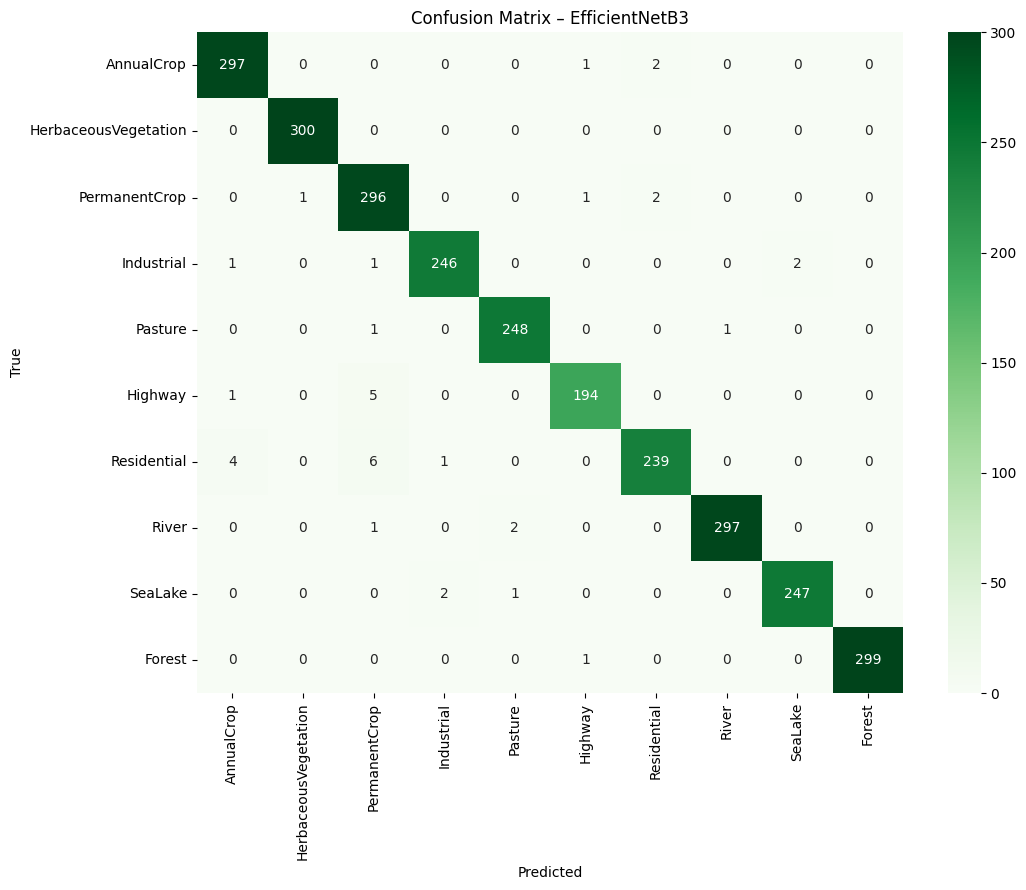

In [23]:
# Confusion matrix & classification report – EfficientNet
print('Running predictions on test set (EfficientNetB3)...')
y_true_eff, y_pred_eff = get_predictions(eff_model, test_seq_eff)

cm_eff = confusion_matrix(y_true_eff, y_pred_eff)
print('\nClassification Report – EfficientNetB3')
print(classification_report(y_true_eff, y_pred_eff, target_names=classes))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix – EfficientNetB3')
plt.tight_layout()
plt.show()


         Model Test Loss Accuracy Top-3 Accuracy    AUC Precision Recall Input Size
    Custom CNN    0.1337   0.9567         0.9970 0.9985    0.9618 0.9522      64×64
EfficientNetB3    0.1637   0.9863         1.0000 0.9993    0.9881 0.9859    224×224


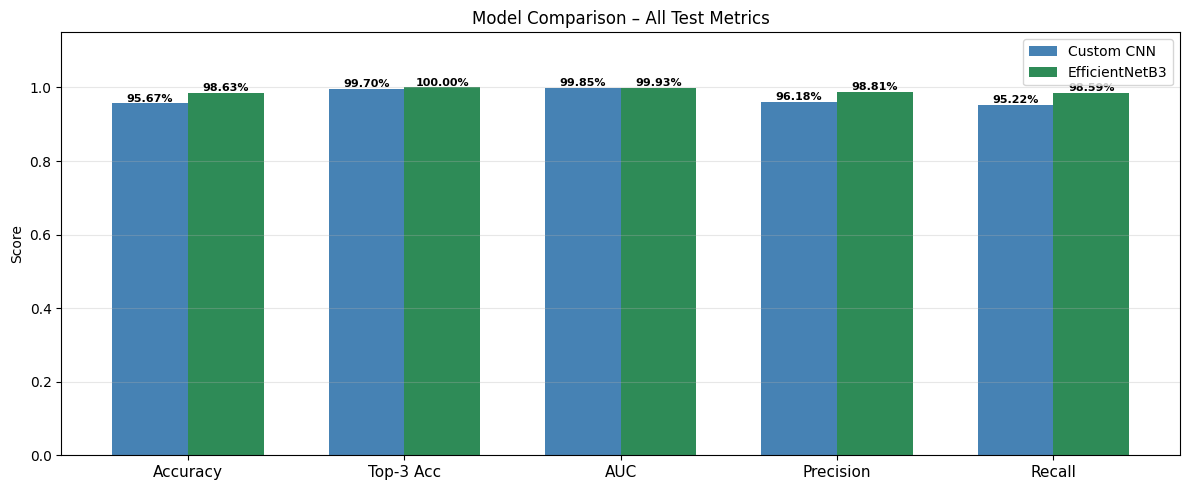

In [24]:
comparison = pd.DataFrame({
    'Model':          ['Custom CNN',     'EfficientNetB3'],
    'Test Loss':      [cnn_test_loss,    eff_test_loss],
    'Accuracy':       [cnn_test_acc,     eff_test_acc],
    'Top-3 Accuracy': [cnn_test_top3,    eff_test_top3],
    'AUC':            [cnn_test_auc,     eff_test_auc],
    'Precision':      [cnn_test_prec,    eff_test_prec],
    'Recall':         [cnn_test_rec,     eff_test_rec],
    'Input Size':     ['64×64',           '224×224'],
})

# Format floats
float_cols = ['Test Loss','Accuracy','Top-3 Accuracy','AUC','Precision','Recall']
for col in float_cols:
    comparison[col] = comparison[col].apply(lambda x: f'{x:.4f}')
print(comparison.to_string(index=False))

# Bar chart – all metrics side by side
metric_labels = ['Accuracy', 'Top-3 Acc', 'AUC', 'Precision', 'Recall']
cnn_vals = [cnn_test_acc, cnn_test_top3, cnn_test_auc, cnn_test_prec, cnn_test_rec]
eff_vals = [eff_test_acc, eff_test_top3, eff_test_auc, eff_test_prec, eff_test_rec]

x    = np.arange(len(metric_labels))
w    = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, cnn_vals, w, label='Custom CNN',     color='steelblue')
b2 = ax.bar(x + w/2, eff_vals, w, label='EfficientNetB3', color='seagreen')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score'); ax.set_title('Model Comparison – All Test Metrics')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
def predict_image(image_path, model, classes, img_size, preprocess=True):
    """
    Predict the land-cover class of a single satellite image.

    Args:
        image_path : str  – full path to the image file
        model      : keras Model – trained CNN or EfficientNet
        classes    : list of str – class names ordered by label index
        img_size   : int  – resize target (64 for CNN, 224 for EfficientNet)
        preprocess : bool – apply Median Blur → CLAHE pipeline (default True)

    Returns:
        dict with predicted class, confidence, and full probability breakdown
    """
    # ── 1. Load & resize ──────────────────────────────────────────────────────
    img = Image.open(image_path).convert('RGB')
    img = img.resize((img_size, img_size))
    arr = np.array(img)

    # ── 2. Apply same preprocessing used during training ──────────────────────
    if preprocess:
        arr = apply_preprocessing(arr)   # Median Blur → CLAHE → float32 [0,1]
    else:
        arr = arr.astype(np.float32) / 255.0

    # ── 3. Add batch dimension: (H, W, 3) → (1, H, W, 3) ────────────────────
    arr = np.expand_dims(arr, axis=0)

    # ── 4. Predict ────────────────────────────────────────────────────────────
    probs      = model.predict(arr, verbose=0)[0]   # shape: (num_classes,)
    pred_idx   = np.argmax(probs)
    pred_class = classes[pred_idx]
    confidence = probs[pred_idx]

    return {
        'predicted_class': pred_class,
        'confidence':      confidence,
        'probabilities':   dict(zip(classes, probs))
    }


def predict_and_show(image_path, model, classes, img_size, model_name='Model'):
    """
    Predict and display the image with a probability bar chart.
    """
    result = predict_image(image_path, model, classes, img_size)

    pred_class = result['predicted_class']
    confidence = result['confidence']
    probs      = result['probabilities']

    # Sort probabilities high → low
    sorted_probs = dict(sorted(probs.items(), key=lambda x: x[1], reverse=True))

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))

    # Left: original image
    img = Image.open(image_path).convert('RGB')
    ax_img.imshow(img)
    ax_img.set_title(
        f'Prediction: {pred_class}\nConfidence: {confidence:.2%}',
        fontsize=13, fontweight='bold',
        color='green' if confidence >= 0.7 else 'orange'
    )
    ax_img.axis('off')

    # Right: probability bar chart
    colors = ['steelblue'] * len(sorted_probs)
    colors[0] = 'seagreen'   # highlight top prediction
    bars = ax_bar.barh(
        list(sorted_probs.keys()),
        list(sorted_probs.values()),
        color=colors, edgecolor='white'
    )
    for bar, val in zip(bars, sorted_probs.values()):
        ax_bar.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val:.2%}', va='center', fontsize=9)
    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_xlabel('Probability')
    ax_bar.set_title(f'{model_name} – Class Probabilities', fontsize=11)
    ax_bar.invert_yaxis()   # highest probability on top
    ax_bar.grid(axis='x', alpha=0.3)

    plt.suptitle(os.path.basename(image_path), fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()

    print(f'  Predicted : {pred_class}')
    print(f'  Confidence: {confidence:.2%}')
    return result


# ── Compare both models on the same image ─────────────────────────────────────
def compare_models_on_image(image_path, classes):
    """
    Run CNN and EfficientNet on the same image and display results side by side.
    """
    r_cnn = predict_image(image_path, cnn_model, classes, IMG_SIZE)
    r_eff = predict_image(image_path, eff_model, classes, IMG_SIZE_EFF)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Original image
    axes[0].imshow(Image.open(image_path).convert('RGB'))
    axes[0].set_title('Input Image', fontsize=12)
    axes[0].axis('off')

    for ax, result, name in zip(
        axes[1:],
        [r_cnn, r_eff],
        ['Custom CNN', 'EfficientNetB3']
    ):
        sorted_p = dict(sorted(result['probabilities'].items(),
                                key=lambda x: x[1], reverse=True))
        colors = ['seagreen'] + ['steelblue'] * (len(sorted_p) - 1)
        bars = ax.barh(list(sorted_p.keys()), list(sorted_p.values()),
                       color=colors, edgecolor='white')
        for bar, val in zip(bars, sorted_p.values()):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val:.1%}', va='center', fontsize=8)
        ax.set_xlim(0, 1.2)
        ax.set_xlabel('Probability')
        ax.set_title(
            f'{name}\n→ {result["predicted_class"]} ({result["confidence"]:.2%})',
            fontsize=10, fontweight='bold'
        )
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

    plt.suptitle(os.path.basename(image_path), fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()

    print(f'  CNN            → {r_cnn["predicted_class"]:25s} ({r_cnn["confidence"]:.2%})')
    print(f'  EfficientNetB3 → {r_eff["predicted_class"]:25s} ({r_eff["confidence"]:.2%})')
    agree = r_cnn['predicted_class'] == r_eff['predicted_class']
    print(f'  Models agree: {"✅ Yes" if agree else "❌ No"}')


print('Prediction functions ready!')
print('Usage:')
print('  predict_and_show(image_path, cnn_model, classes, IMG_SIZE, "Custom CNN")')
print('  predict_and_show(image_path, eff_model, classes, IMG_SIZE_EFF, "EfficientNetB3")')
print('  compare_models_on_image(image_path, classes)')


Prediction functions ready!
Usage:
  predict_and_show(image_path, cnn_model, classes, IMG_SIZE, "Custom CNN")
  predict_and_show(image_path, eff_model, classes, IMG_SIZE_EFF, "EfficientNetB3")
  compare_models_on_image(image_path, classes)


Image : /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/Pasture/Pasture_473.jpg
True label: Highway



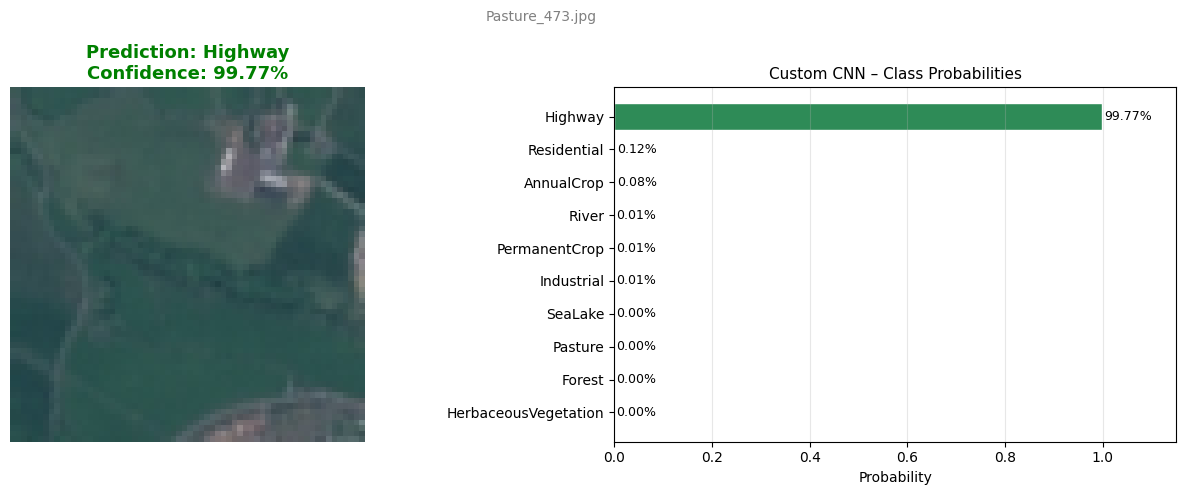

  Predicted : Highway
  Confidence: 99.77%


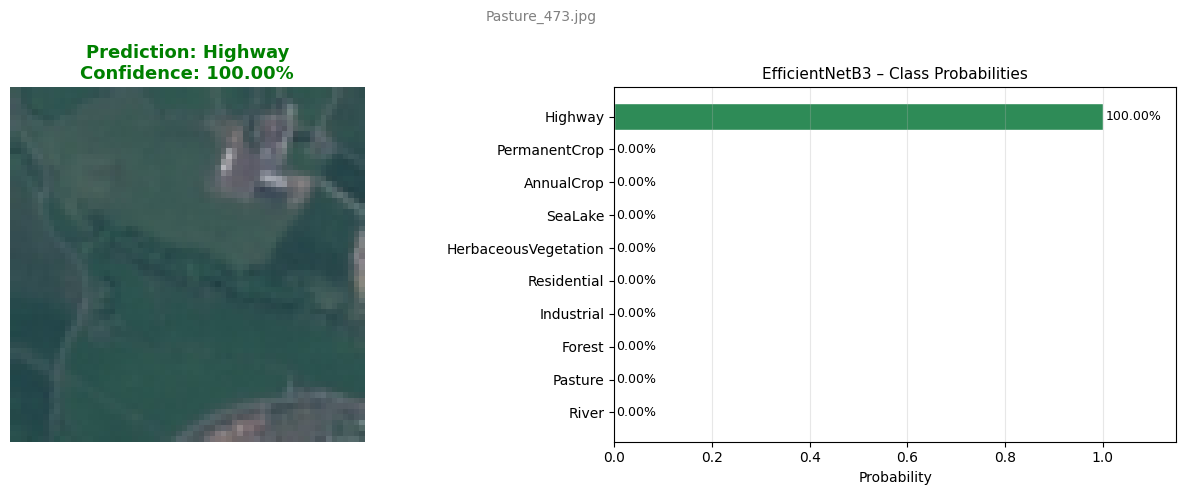

  Predicted : Highway
  Confidence: 100.00%

── Model Comparison ──


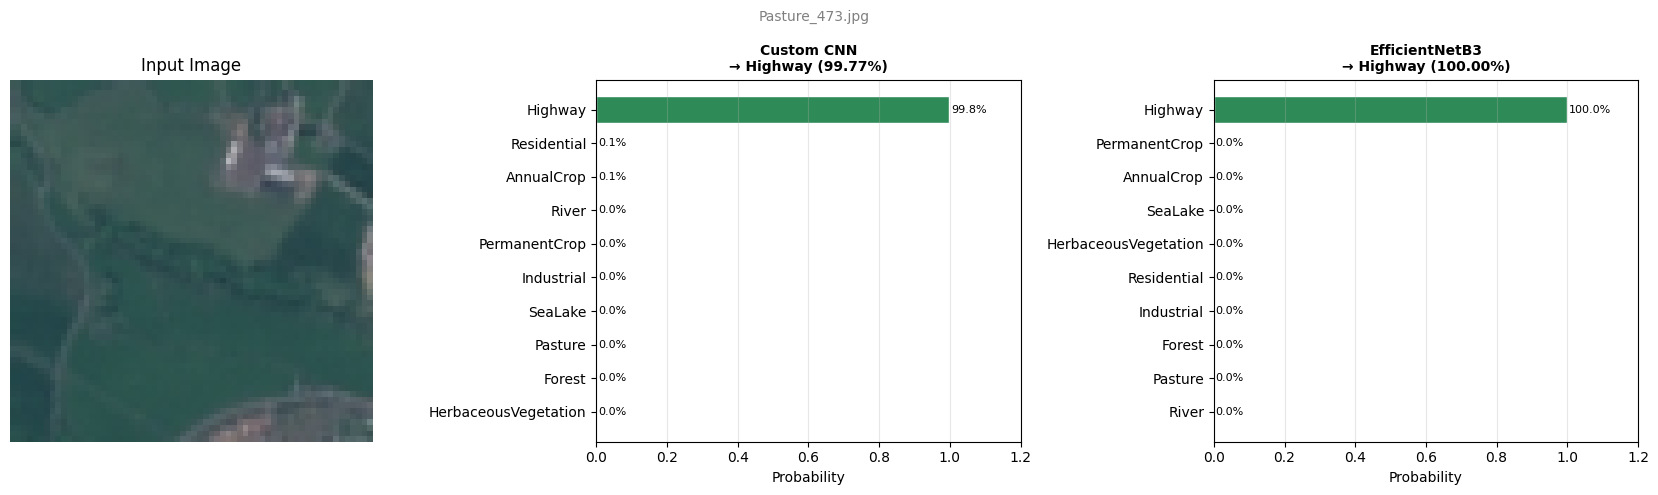

  CNN            → Highway                   (99.77%)
  EfficientNetB3 → Highway                   (100.00%)
  Models agree: ✅ Yes


In [26]:
# ── Example: predict a single image ───────────────────────────────────────────
# Change this path to any .jpg satellite image you want to test
IMAGE_PATH = test_df['full_path'].iloc[4]   # grab a random test image

print(f'Image : {IMAGE_PATH}')
print(f'True label: {test_df.iloc[42]["ClassName"]}')
print()

# ── Single model prediction ────────────────────────────────────────────────────
predict_and_show(IMAGE_PATH, cnn_model, classes, IMG_SIZE,     model_name='Custom CNN')
predict_and_show(IMAGE_PATH, eff_model, classes, IMG_SIZE_EFF, model_name='EfficientNetB3')

# ── Side-by-side comparison ────────────────────────────────────────────────────
print('\n── Model Comparison ──')
compare_models_on_image(IMAGE_PATH, classes)


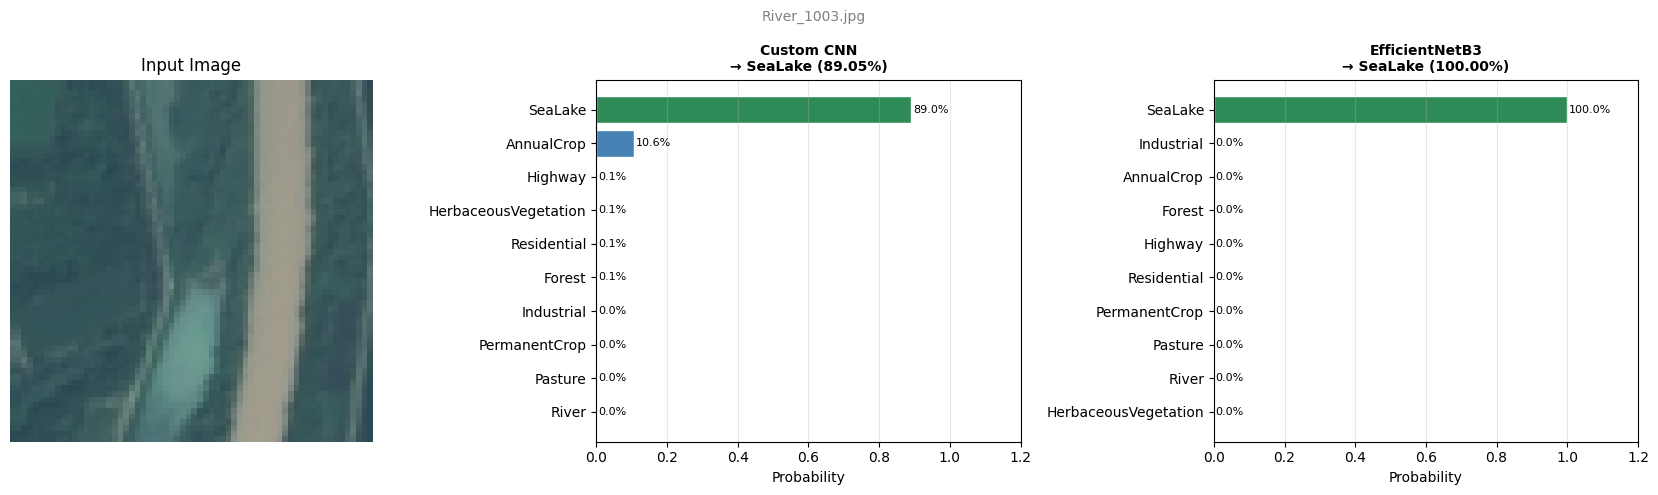

  CNN            → SeaLake                   (89.05%)
  EfficientNetB3 → SeaLake                   (100.00%)
  Models agree: ✅ Yes


In [27]:
# ── Predict from your own custom image path ────────────────────────────────────
# Replace the path below with any Sentinel-2 image on disk
CUSTOM_PATH = '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/River/River_1003.jpg'

if os.path.exists(CUSTOM_PATH):
    compare_models_on_image(CUSTOM_PATH, classes)
else:
    print(f'File not found: {CUSTOM_PATH}')
    print('Change CUSTOM_PATH to a valid image path and re-run.')


In [31]:
eff_model.save("final_efficient_net.keras")